# NYC Urban Forestry Analysis

## Purpose and dataset orientation

This notebook inspects the official **2015 Street Tree Census – Tree Data** published by NYC Parks through NYC Open Data. It documents structure, completeness, category consistency, and diameter anomalies without overwriting or silently correcting source values.

**Exploratory question:** How do recorded street-tree health patterns differ across NYC boroughs and common species, and where might maintenance attention be prioritized?

> Compact server-side queries are used; the full dataset is not downloaded to the phone.

## Data context

- **Source:** [NYC Open Data — 2015 Street Tree Census](https://data.cityofnewyork.us/Environment/2015-Street-Tree-Census-Tree-Data/uvpi-gqnh)
- **Publisher:** NYC Department of Parks & Recreation
- **Collection period:** May 2015–October 2016
- **Unit of observation:** A tree point recorded during a specific survey, not a permanent identifier across censuses
- **Measurement definition:** Workers measured circumference near breast height. Census processing divided it by 3.14159 and rounded it to create `tree_dbh` in inches.

The source values remain unchanged. Flags below exist only in compact summary tables.

In [1]:
import json
from urllib.parse import urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_URL = "https://data.cityofnewyork.us/resource/uvpi-gqnh.json"

def soda_query(select="*", where=None, group=None, order=None, limit=None):
    """Return a compact NYC Open Data API result as a DataFrame."""
    params = {"$select": select}
    for key, value in [("$where", where), ("$group", group), ("$order", order)]:
        if value is not None:
            params[key] = value
    if limit is not None:
        params["$limit"] = str(limit)
    with urlopen(BASE_URL + "?" + urlencode(params), timeout=90) as response:
        return pd.DataFrame(json.load(response))

print("Ready to query compact summaries from NYC Open Data.")

Ready to query compact summaries from NYC Open Data.


## Small live preview

Five rows are retrieved to understand the structure. They are not used to estimate population patterns.

In [2]:
preview_fields = ", ".join([
    "tree_id", "created_at", "tree_dbh", "status", "health", "spc_common",
    "steward", "guards", "sidewalk", "problems", "boroname", "nta_name",
    "latitude", "longitude"
])
preview = soda_query(select=preview_fields, limit=5)
display(preview)

,tree_id,created_at,tree_dbh,status,health,spc_common,steward,guards,sidewalk,problems,boroname,nta_name,latitude,longitude
0,180683,2015-08-27T00:00:00.000,3,Alive,Fair,red maple,None,None,NoDamage,None,Queens,Forest Hills,40.72309177,-73.84421522
1,200540,2015-09-03T00:00:00.000,21,Alive,Fair,pin oak,None,None,Damage,Stones,Queens,Whitestone,40.79411067,-73.81867946
2,204026,2015-09-05T00:00:00.000,3,Alive,Good,honeylocust,1or2,None,Damage,None,Brooklyn,East Williamsburg,40.71758074,-73.9366077
3,204337,2015-09-05T00:00:00.000,10,Alive,Good,honeylocust,None,None,Damage,Stones,Brooklyn,East Williamsburg,40.71353749,-73.93445616
4,189565,2015-08-30T00:00:00.000,21,Alive,Good,American linden,None,None,Damage,Stones,Brooklyn,Park Slope-Gowanus,40.66677776,-73.97597938


## Dimensions and identifier uniqueness

In [3]:
identity = soda_query(
    select="count(*) as total_records, count(distinct tree_id) as unique_tree_ids"
).apply(pd.to_numeric)
identity["duplicate_tree_ids"] = identity.total_records - identity.unique_tree_ids
display(identity)

,total_records,unique_tree_ids,duplicate_tree_ids
0,683788,683788,0


## Status, health, and meaningful missingness

The official dictionary says health is not recorded for dead trees or stumps. Those blanks are not treated as failed responses.

In [4]:
status_health = soda_query(
    select="status, health, count(*) as count",
    group="status, health", order="status, health"
)
status_health["health"] = status_health["health"].fillna("Not applicable / blank")
status_health["count"] = pd.to_numeric(status_health["count"])
display(status_health)

,status,health,count
0,Alive,Fair,96504
1,Alive,Good,528850
2,Alive,Poor,26818
3,Alive,Not applicable / blank,1
4,Dead,Not applicable / blank,13961
5,Stump,Not applicable / blank,17654


In [5]:
analysis_fields = [
    "tree_id", "tree_dbh", "status", "health", "spc_common", "steward",
    "guards", "sidewalk", "problems", "zipcode", "boroname", "nta_name",
    "latitude", "longitude"
]
select_parts = ["count(*) as total"] + [
    f"count({field}) as {field}_present" for field in analysis_fields
]
presence = soda_query(
    select=", ".join(select_parts), where="status='Alive'"
).apply(pd.to_numeric)
total_alive = int(presence.loc[0, "total"])
missingness = pd.DataFrame([
    {
        "variable": field,
        "missing_count": total_alive - int(presence.loc[0, f"{field}_present"]),
    }
    for field in analysis_fields
])
missingness["missing_percent"] = (
    100 * missingness.missing_count / total_alive
).round(5)
display(missingness.sort_values(["missing_count", "variable"], ascending=[False, True]))

,variable,missing_count,missing_percent
8,problems,49,0.00751
4,spc_common,5,0.00077
6,guards,1,0.00015
3,health,1,0.00015
7,sidewalk,1,0.00015
10,boroname,0,0.00000
12,latitude,0,0.00000
13,longitude,0,0.00000
11,nta_name,0,0.00000
2,status,0,0.00000


## Category consistency

Blanks are displayed explicitly instead of replaced.

In [6]:
category_fields = ["status", "health", "steward", "guards", "sidewalk", "curb_loc", "user_type"]
category_tables = {}
for field in category_fields:
    table = soda_query(
        select=f"{field}, count(*) as count", group=field, order="count DESC"
    )
    table[field] = table[field].fillna("Blank")
    table["count"] = pd.to_numeric(table["count"])
    category_tables[field] = table
    print(f"\n{field}")
    display(table)

,status,count
0,Alive,652173
1,Stump,17654
2,Dead,13961


,health,count
0,Good,528850
1,Fair,96504
2,Blank,31616
3,Poor,26818


,steward,count
0,None,487823
1,1or2,143557
2,Blank,31615
3,3or4,19183
4,4orMore,1610


,guards,count
0,None,572306
1,Helpful,51866
2,Blank,31616
3,Harmful,20252
4,Unsure,7748


,sidewalk,count
0,NoDamage,464978
1,Damage,187194
2,Blank,31616


,curb_loc,count
0,OnCurb,656896
1,OffsetFromCurb,26892


,user_type,count
0,TreesCount Staff,296284
1,Volunteer,217518
2,NYC Parks Staff,169986



status

health

steward

guards

sidewalk

curb_loc

user_type


## Living-tree diameter distribution

Counts by recorded diameter are retrieved, so 652,173 detailed rows do not need to be downloaded.

In [7]:
dbh_distribution = soda_query(
    select="tree_dbh, count(*) as count", where="status='Alive'",
    group="tree_dbh", order="tree_dbh", limit=1000
).apply(pd.to_numeric)
dbh_distribution = dbh_distribution.sort_values("tree_dbh").reset_index(drop=True)

def weighted_percentile(values, weights, probability):
    target = probability * weights.sum()
    index = np.searchsorted(weights.cumsum().to_numpy(), target, side="left")
    return values.iloc[min(index, len(values) - 1)]

percentiles = pd.DataFrame({
    "percentile": [25, 50, 75, 95, 99, 99.9],
    "diameter_inches": [
        weighted_percentile(dbh_distribution.tree_dbh, dbh_distribution["count"], p)
        for p in [0.25, 0.50, 0.75, 0.95, 0.99, 0.999]
    ]
})
display(percentiles)

,percentile,diameter_inches
0,25.0,5
1,50.0,10
2,75.0,16
3,95.0,29
4,99.0,37
5,99.9,47


In [8]:
total_living = int(dbh_distribution["count"].sum())
diameter_checks = pd.DataFrame([
    {"condition": "Recorded diameter = 0", "count": int(dbh_distribution.loc[dbh_distribution.tree_dbh.eq(0), "count"].sum())},
    {"condition": "Recorded diameter > 60", "count": int(dbh_distribution.loc[dbh_distribution.tree_dbh.gt(60), "count"].sum())},
    {"condition": "Recorded diameter > 100", "count": int(dbh_distribution.loc[dbh_distribution.tree_dbh.gt(100), "count"].sum())},
    {"condition": "Recorded diameter > 200", "count": int(dbh_distribution.loc[dbh_distribution.tree_dbh.gt(200), "count"].sum())},
])
diameter_checks["percent_of_living_trees"] = (
    100 * diameter_checks["count"] / total_living
).round(5)
display(diameter_checks)
print("Minimum:", int(dbh_distribution.tree_dbh.min()), "inches")
print("Maximum:", int(dbh_distribution.tree_dbh.max()), "inches")

,condition,count,percent_of_living_trees
0,Recorded diameter = 0,222,0.03404
1,Recorded diameter > 60,150,0.02300
2,Recorded diameter > 100,67,0.01027
3,Recorded diameter > 200,20,0.00307


Minimum: 0 inches
Maximum: 425 inches


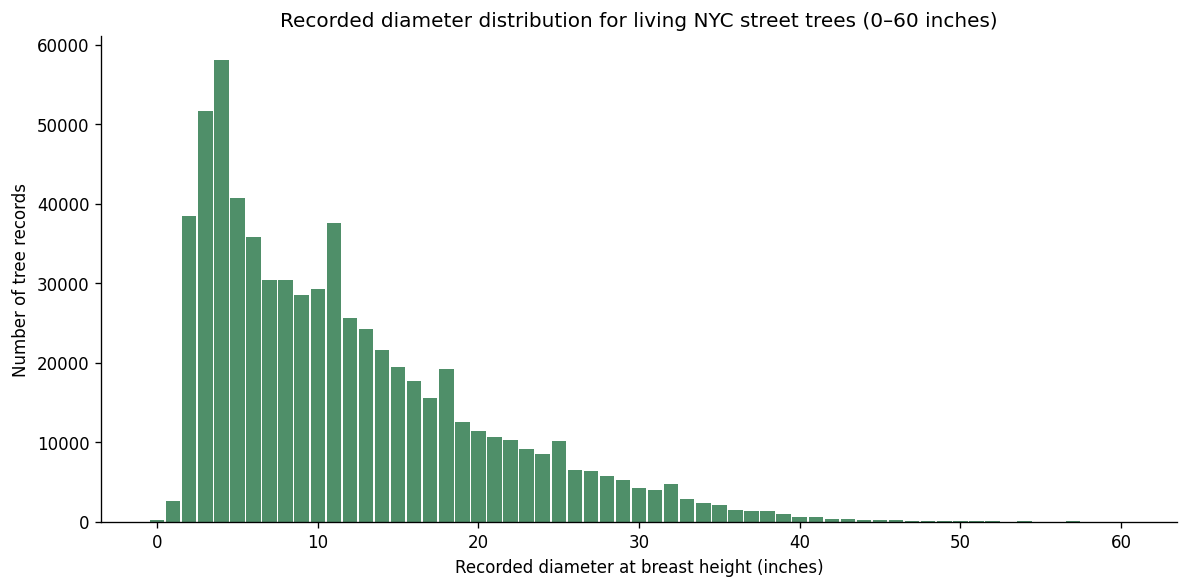

In [9]:
plot_data = dbh_distribution.loc[dbh_distribution.tree_dbh.le(60)]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_data.tree_dbh, plot_data["count"], color="#4f8f69", width=0.9)
ax.set(title="Recorded diameter distribution for living NYC street trees (0–60 inches)",
       xlabel="Recorded diameter at breast height (inches)",
       ylabel="Number of tree records")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Maximum-value interpretation check

The maximum is `tree_dbh = 425` for a swamp white oak. Officially this is already processed diameter. The calculations below test possible error scenarios without correcting the record.

In [10]:
recorded_max = 425
interpretations = pd.DataFrame({
    "scenario": [
        "Official meaning: recorded diameter",
        "If 425 were unconverted inches of circumference",
        "If 425 were centimeters of circumference",
        "If a decimal were omitted (42.5 inches)"
    ],
    "diameter_inches": [
        recorded_max, recorded_max / np.pi,
        recorded_max / np.pi / 2.54, recorded_max / 10
    ]
})
interpretations["diameter_inches"] = interpretations.diameter_inches.round(2)
display(interpretations)
print("Circumference implied by the official 425-inch diameter:",
      round(recorded_max * np.pi, 1), "inches")

,scenario,diameter_inches
0,Official meaning: recorded diameter,425.00
1,If 425 were unconverted inches of circumference,135.28
2,If 425 were centimeters of circumference,53.26
3,If a decimal were omitted (42.5 inches),42.50


Circumference implied by the official 425-inch diameter: 1335.2 inches


## Inspection decisions

1. Preserve every original source value.
2. Keep `Not applicable` distinct from `No response`.
3. Do not automatically replace numerical missing values with zero.
4. Call zero diameters **recorded zeros** because their meaning is unresolved.
5. Keep extreme diameters, flag them in derived analysis, and compare alternative inclusion rules.
6. Prefer medians and interquartile ranges for initial diameter summaries.
7. Treat health as the surveyor's perception at collection time, not a current clinical assessment.

## Current observations and limitations

- IDs are unique within this census but do not identify the same physical tree across census years.
- Principal categories use a small, consistent set of labels.
- Genuine missingness among living trees is negligible.
- The central diameter distribution is credible, but a very small extreme tail is ambiguous.
- Raw field circumference is unavailable; anomalous processed values cannot be reconstructed.
- Measurement, unit, decimal, multi-stem, location-association, or processing errors remain possible.
- Collection occurred in 2015–2016, so the data do not establish present-day condition.

### Potential collection improvements

Retain raw circumference; record units explicitly; add a separate `not measured` option; warn about unusual ranges; support multi-stem measurements; preserve correction history; and use timestamped location or image confirmation where appropriate.

## Reproducibility and AI disclosure

Aggregate results are retrieved directly from NYC Open Data. AI assisted with query construction, calculation checks, documentation, and limitation framing. Interpretations were reviewed collaboratively, and no source value was silently altered.